# Structure-Constant Layout Variant Benchmarks

This notebook contains the quick benchmark run for the exact structure-constant layout variants introduced in `CyclotomicField`. The committed outputs are viewable in GitHub.

In [1]:
import json
from pathlib import Path

root = Path.cwd()
if not (root / 'benchmarks').exists():
    root = root.parent
records = json.loads((root / 'benchmarks/results/structure_variants_quick.json').read_text())
len(records), records[0]

records: 183
structure multiplication records: 60
orders: [5, 8, 12, 15]
generated_at_utc: 2026-04-26T13:09:58+00:00

n=5: best full-density variant is structure_sparse_skip_zero at 396.4k ops/s (2.32x nested)
n=8: best full-density variant is structure_sparse at 422.8k ops/s (2.79x nested)
n=12: best full-density variant is structure_sparse at 342.8k ops/s (2.31x nested)


## Reproduction command

```bash
cargo run --release --example perf_bench -- --quick > benchmarks/results/structure_variants_quick.json
python3 benchmarks/render_structure_variants_notebook.py
```

## Full-Density Table

| order | representation | ops/s | speedup vs nested |
|---:|---|---:|---:|
| 5 | `structure` | 170.6k | 1.00x |
| 5 | `structure_flat` | 268.3k | 1.57x |
| 5 | `structure_sparse` | 358.4k | 2.10x |
| 5 | `structure_sparse_skip_zero` | 396.4k | 2.32x |
| 8 | `structure` | 151.4k | 1.00x |
| 8 | `structure_flat` | 270.1k | 1.78x |
| 8 | `structure_sparse` | 422.8k | 2.79x |
| 8 | `structure_sparse_skip_zero` | 421.8k | 2.79x |
| 12 | `structure` | 148.1k | 1.00x |
| 12 | `structure_flat` | 236.4k | 1.60x |
| 12 | `structure_sparse` | 342.8k | 2.31x |
| 12 | `structure_sparse_skip_zero` | 329.7k | 2.23x |

## Half-Density Table

| order | representation | ops/s | speedup vs nested |
|---:|---|---:|---:|
| 5 | `structure` | 293.1k | 1.00x |
| 5 | `structure_flat` | 401.2k | 1.37x |
| 5 | `structure_sparse` | 670.7k | 2.29x |
| 5 | `structure_sparse_skip_zero` | 1.34M | 4.56x |
| 8 | `structure` | 336.4k | 1.00x |
| 8 | `structure_flat` | 463.5k | 1.38x |
| 8 | `structure_sparse` | 1.09M | 3.25x |
| 8 | `structure_sparse_skip_zero` | 2.75M | 8.18x |
| 12 | `structure` | 247.4k | 1.00x |
| 12 | `structure_flat` | 372.2k | 1.50x |
| 12 | `structure_sparse` | 621.7k | 2.51x |
| 12 | `structure_sparse_skip_zero` | 891.6k | 3.60x |

## Full-density throughput

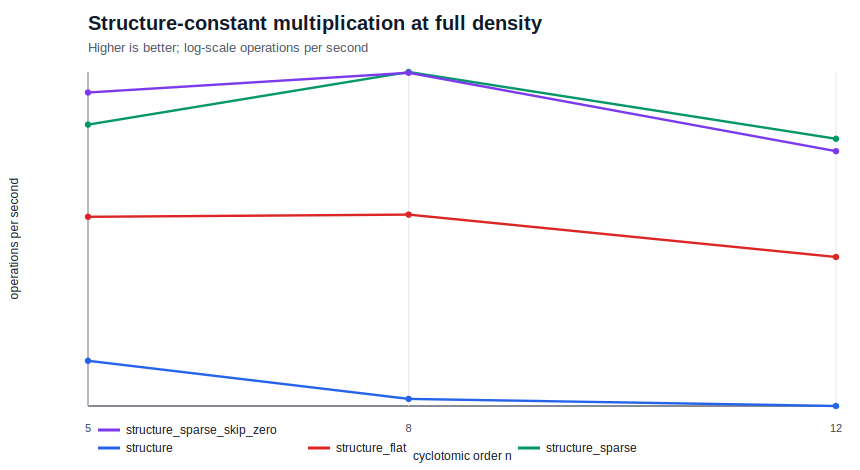

In [2]:
# Rendered from benchmarks/results/structure_variants_quick.json

## Density sensitivity

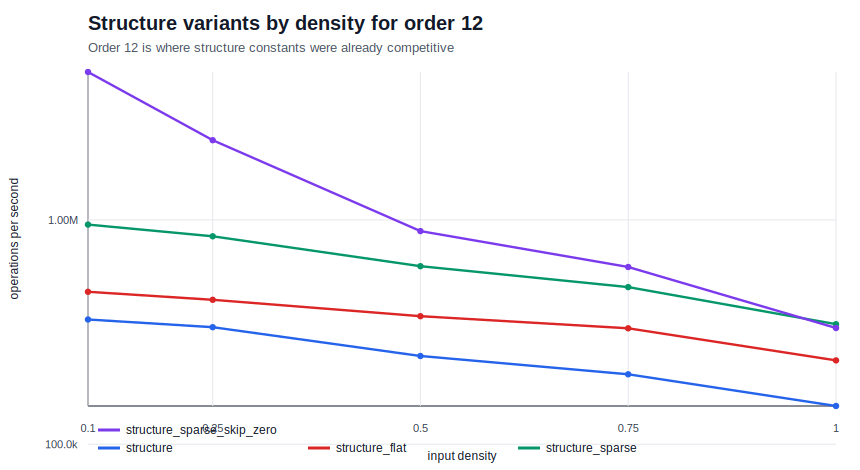

In [3]:
# Rendered from benchmarks/results/structure_variants_quick.json

## Best sparse variant by density

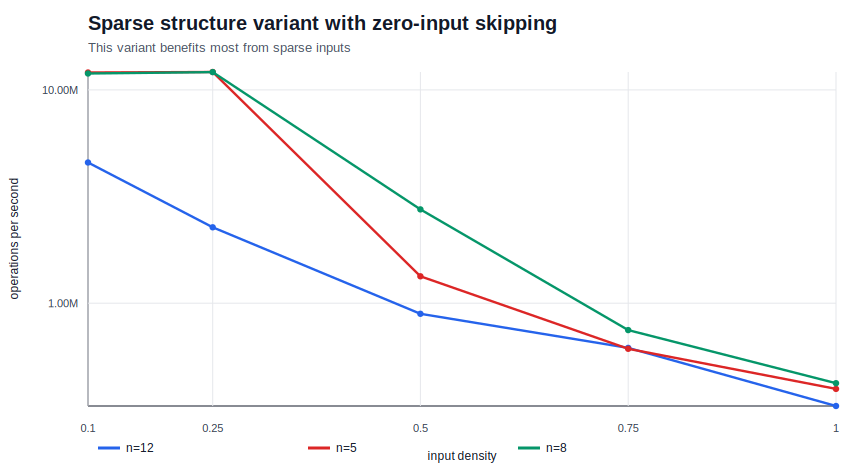

In [4]:
# Rendered from benchmarks/results/structure_variants_quick.json

## Notes

- `structure` is the original nested `Vec<Vec<Vec<Q>>>` layout.
- `structure_flat` uses one contiguous tensor.
- `structure_sparse` stores only nonzero constants.
- `structure_sparse_skip_zero` also skips zero input coefficients.
- These are exact `rug::Rational` benchmarks, not approximate float benchmarks.